<h2>Quick Start: Creating Sample-wise Unlearnable Examples</h2>

<h3>Prepare Data</h3>

In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Prepare Dataset
train_transform = [
    transforms.ToTensor()
]
test_transform = [
    transforms.ToTensor()
]
train_transform = transforms.Compose(train_transform)
test_transform = transforms.Compose(test_transform)

clean_train_dataset = datasets.CIFAR10(root='/data1/mjli/Code/kerdeq/data/', train=True, download=True, transform=train_transform)
clean_test_dataset = datasets.CIFAR10(root='/data1/mjli/Code/kerdeq/data/', train=False, download=True, transform=test_transform)

### No shuffle, easy to perturb image
clean_train_loader = DataLoader(dataset=clean_train_dataset, batch_size=128,
                                shuffle=False, pin_memory=True,
                                drop_last=False, num_workers=2)
clean_test_loader = DataLoader(dataset=clean_test_dataset, batch_size=128,
                                shuffle=False, pin_memory=True,
                                drop_last=False, num_workers=2)

c:\Users\desktop\Often\conda\envs\gpu\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


<h3>Prepare Model</h3>

In [2]:
from models.ResNet import ResNet18

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True

base_model = ResNet18()
base_model = base_model.cuda()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=base_model.parameters(), lr=0.1, weight_decay=0.0005, momentum=0.9)


c:\Users\desktop\Often\conda\envs\gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h3>Prepare Perturbation Generator Tool</h3>

In [3]:
import numpy as np
from torch.autograd import Variable

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')


class PerturbationTool():
    def __init__(self, seed=0, epsilon=0.03137254901, num_steps=20, step_size=0.00784313725):
        self.epsilon = epsilon
        self.num_steps = num_steps
        self.step_size = step_size
        self.seed = seed
        np.random.seed(seed)

    def random_noise(self, noise_shape=[10, 3, 32, 32]):
        random_noise = torch.FloatTensor(*noise_shape).uniform_(-self.epsilon, self.epsilon).to(device)
        return random_noise

    def min_min_attack(self, images, labels, model, optimizer, criterion, random_noise=None, sample_wise=False):
        if random_noise is None:
            random_noise = torch.FloatTensor(*images.shape).uniform_(-self.epsilon, self.epsilon).to(device)

        perturb_img = Variable(images.data + random_noise, requires_grad=True)
        perturb_img = Variable(torch.clamp(perturb_img, 0, 1), requires_grad=True)
        eta = random_noise
        for _ in range(self.num_steps):
            opt = torch.optim.SGD([perturb_img], lr=1e-3)
            opt.zero_grad()
            model.zero_grad()
            if isinstance(criterion, torch.nn.CrossEntropyLoss):
                if hasattr(model, 'classify'):
                    model.classify = True
                logits = model(perturb_img)
                loss = criterion(logits, labels)
            else:
                logits, loss = criterion(model, perturb_img, labels, optimizer)
            perturb_img.retain_grad()
            loss.backward()
            eta = self.step_size * perturb_img.grad.data.sign() * (-1)
            perturb_img = Variable(perturb_img.data + eta, requires_grad=True)
            eta = torch.clamp(perturb_img.data - images.data, -self.epsilon, self.epsilon)
            perturb_img = Variable(images.data + eta, requires_grad=True)
            perturb_img = Variable(torch.clamp(perturb_img, 0, 1), requires_grad=True)

        return perturb_img, eta

    
noise_generator = PerturbationTool(epsilon=16/255, num_steps=10, step_size=4/255)


### Test noise_generator
images= torch.randn([1,3,32,32]).cuda()
labels= torch.ones([1]).long().cuda()

# noise_generator.min_min_attack(images, labels, base_model, optimizer, criterion, 
#                                                           random_noise=torch.zeros_like(images).cuda())


<h3>Generate Error-Minimizing Noise</h3>

In [4]:
from tqdm import tqdm
import torch

# ========== Samplewise: 每个样本一个噪声 ==========
num_samples = len(clean_train_dataset)  # 50000
noise = torch.zeros([num_samples, 3, 32, 32], device=device)

# 重要：samplewise 要求数据顺序固定，不能 shuffle
# 你的 DataLoader 已经设置了 shuffle=False，正确

data_iter = iter(clean_train_loader)
condition = True
global_batch_idx = 0  # 记录当前处理到第几个样本

while condition:
    # ========== 阶段1：训练 base model ==========
    base_model.train()
    for param in base_model.parameters():
        param.requires_grad = True
    
    for j in range(10):
        images, labels = next(data_iter)
        images, labels = images.cuda(), labels.cuda()
        
        # Samplewise: 取当前 batch 对应的噪声
        batch_size = images.size(0)
        start_idx = global_batch_idx
        end_idx = global_batch_idx + batch_size
        current_noise = noise[start_idx:end_idx]  # [B, 3, 32, 32]
        
        # 加噪声并 clamp
        images = torch.clamp(images + current_noise, 0, 1)
        
        logits = base_model(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        global_batch_idx += batch_size
        # 如果超出数据集，重置
        if global_batch_idx >= num_samples:
            global_batch_idx = 0
            data_iter = iter(clean_train_loader)
        
        print(f"training one batch!")
    
    print(f"Finish training base model for 10 steps, start perturbation...")

    # ========== 阶段2：更新噪声 ==========
    for param in base_model.parameters():
        param.requires_grad = False
    
    batch_start_idx = 0
    for images, labels in tqdm(clean_train_loader, total=len(clean_train_loader)):
        images, labels = images.cuda(), labels.cuda()
        batch_size = images.size(0)
        
        # Samplewise: 取当前 batch 对应的噪声作为初始值
        current_noise = noise[batch_start_idx:batch_start_idx + batch_size]
        
        base_model.eval()
        perturb_img, eta = noise_generator.min_min_attack(
            images, labels, base_model, optimizer, criterion, 
            random_noise=current_noise  # 传入当前噪声
        )
        
        # Samplewise: 直接按位置更新噪声
        noise[batch_start_idx:batch_start_idx + batch_size] += eta.detach()
        
        # 对噪声进行 clamp
        noise[batch_start_idx:batch_start_idx + batch_size] = torch.clamp(
            noise[batch_start_idx:batch_start_idx + batch_size],
            -noise_generator.epsilon, 
            noise_generator.epsilon
        )
        
        batch_start_idx += batch_size
        print(f"compute all noise for one batch!")
    
    # 重置索引
    batch_start_idx = 0
    
    print(f"Finish perturbation, start evaluation...")

    # ========== 阶段3：评估 ==========
    total, correct = 0, 0
    eval_idx = 0
    with torch.no_grad():
        for images, labels in clean_train_loader:
            images, labels = images.cuda(), labels.cuda()
            batch_size = images.size(0)
            
            # Samplewise: 取对应噪声
            current_noise = noise[eval_idx:eval_idx + batch_size]
            images = torch.clamp(images + current_noise, 0, 1)
            
            logits = base_model(images)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            eval_idx += batch_size
    
    acc = correct / total
    print(f'Accuracy: {acc*100:.2f}%')
    
    if acc > 0.9:
        condition = False

training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
Finish training base model for 10 steps, start perturbation...


  0%|          | 1/391 [00:06<41:20,  6.36s/it]

compute all noise for one batch!


  1%|          | 2/391 [00:06<18:04,  2.79s/it]

compute all noise for one batch!


...

compute all noise for one batch!


100%|██████████| 391/391 [01:59<00:00,  3.73it/s]

compute all noise for one batch!


100%|██████████| 391/391 [02:00<00:00,  3.26it/s]


Finish perturbation, start evaluation...
Accuracy: 95.25%


In [5]:
# Examine the noise
print(noise)

tensor([[[[ 6.2745e-02,  6.2745e-02, -4.7059e-02,  ...,  6.2745e-02,
            6.2745e-02,  6.2745e-02],
          [ 6.2745e-02,  6.2745e-02, -4.7059e-02,  ...,  6.2745e-02,
            6.2745e-02, -4.7059e-02],
          [ 0.0000e+00, -6.2745e-02, -6.2745e-02,  ..., -4.7059e-02,
            6.2745e-02,  6.2745e-02],
          ...,
          [ 6.2745e-02,  6.2745e-02, -6.2745e-02,  ...,  6.2745e-02,
            6.2745e-02, -4.7059e-02],
          [-6.2745e-02, -6.2745e-02, -6.2745e-02,  ...,  6.2745e-02,
            6.2745e-02,  6.2745e-02],
          [-6.2745e-02,  0.0000e+00, -1.5686e-02,  ...,  6.2745e-02,
           -4.7059e-02, -6.2745e-02]],

         [[ 6.2745e-02, -6.2745e-02,  0.0000e+00,  ..., -3.1373e-02,
            4.7059e-02,  4.7059e-02],
          [-6.2745e-02,  4.7059e-02,  6.2745e-02,  ..., -6.2745e-02,
           -6.2745e-02, -6.2745e-02],
          [ 0.0000e+00,  6.2745e-02,  6.2745e-02,  ...,  6.2745e-02,
            6.2745e-02,  6.2745e-02],
          ...,
     

<h3>Creat Unlearnable Dataset</h3>

In [6]:
import numpy as np

# Add standard augmentation
train_transform = [
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
]
train_transform = transforms.Compose(train_transform)
clean_train_dataset = datasets.CIFAR10(root='/data1/mjli/Code/kerdeq/data/', train=True, download=True, transform=train_transform)
unlearnable_train_dataset = datasets.CIFAR10(root='/data1/mjli/Code/kerdeq/data/', train=True, download=True, transform=train_transform)

perturb_noise = noise.mul(255).clamp_(0, 255).permute(0, 2, 3, 1).to('cpu').numpy()
unlearnable_train_dataset.data = unlearnable_train_dataset.data.astype(np.float32)

#############Add perturb noise to original images#############
for i in range(len(unlearnable_train_dataset)):
    unlearnable_train_dataset.data[i] += perturb_noise[i]
    unlearnable_train_dataset.data[i] = np.clip(unlearnable_train_dataset.data[i], a_min=0, a_max=255)
unlearnable_train_dataset.data = unlearnable_train_dataset.data.astype(np.uint8)




c:\Users\desktop\Often\conda\envs\gpu\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


<h3>Visualize Clean Images, Error-Minimizing Noise, Unlearnable Images</h3>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


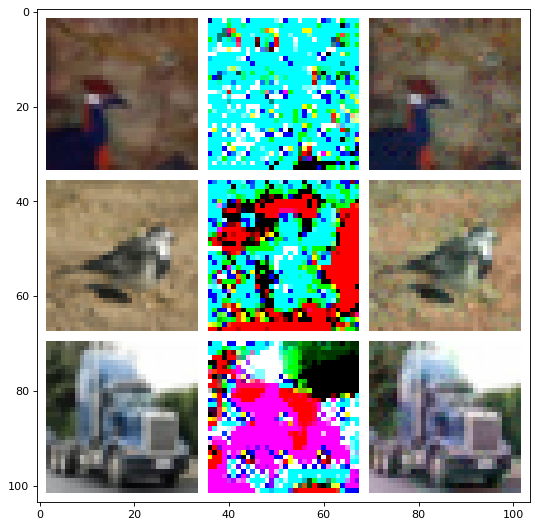

In [22]:
import random
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

def imshow(img):
    fig = plt.figure(figsize=(8, 8), dpi=80, facecolor='w', edgecolor='k')
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
    
def get_pairs_of_imgs(idx):
    clean_img = clean_train_dataset.data[idx]
    unlearnable_img = unlearnable_train_dataset.data[idx]
    clean_img = torchvision.transforms.functional.to_tensor(clean_img)
    unlearnable_img = torchvision.transforms.functional.to_tensor(unlearnable_img)

    x = noise[idx].to("cpu")
    x_min = torch.min(x)
    x_max = torch.max(x)
    noise_norm = (x - x_min) / (x_max - x_min)
    noise_norm = torch.clamp(noise_norm, 0, 1)
    return [clean_img, noise_norm, unlearnable_img]
    
selected_idx = [random.randint(0, 50000) for _ in range(3)]
img_grid = []
for idx in selected_idx:
    img_grid += get_pairs_of_imgs(idx)
    

imshow(torchvision.utils.make_grid(torch.stack(img_grid), nrow=3, pad_value=255))



<h3>Train ResNet18 on Unlearnable Dataset</h3>

In [23]:
from util import AverageMeter

model = ResNet18()
model = model.cuda()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1, weight_decay=0.0005, momentum=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=0)

unlearnable_loader = DataLoader(dataset=unlearnable_train_dataset, batch_size=128,
                                shuffle=True, pin_memory=True,
                                drop_last=False, num_workers=12)


for epoch in range(30):
    # Train
    model.train()
    acc_meter = AverageMeter()
    loss_meter = AverageMeter()
    pbar = tqdm(unlearnable_loader, total=len(unlearnable_loader))
    for images, labels in pbar:
        images, labels = images.cuda(), labels.cuda()
        model.zero_grad()
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        _, predicted = torch.max(logits.data, 1)
        acc = (predicted == labels).sum().item()/labels.size(0)
        acc_meter.update(acc)
        loss_meter.update(loss.item())
        pbar.set_description("Acc %.2f Loss: %.2f" % (acc_meter.avg*100, loss_meter.avg))
    scheduler.step()
    # Eval
    model.eval()
    correct, total = 0, 0
    for i, (images, labels) in enumerate(clean_test_loader):
        images, labels = images.cuda(), labels.cuda()
        with torch.no_grad():
            logits = model(images)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = correct / total
    tqdm.write('Clean Accuracy %.2f\n' % (acc*100))
            

Acc 51.64 Loss: 1.36: 100%|██████████| 391/391 [00:59<00:00,  6.53it/s]


Clean Accuracy 32.02



Acc 70.99 Loss: 0.81: 100%|██████████| 391/391 [00:58<00:00,  6.66it/s]


Clean Accuracy 27.04



Acc 81.02 Loss: 0.55: 100%|██████████| 391/391 [00:58<00:00,  6.71it/s]


...

Clean Accuracy 21.34



Acc 96.98 Loss: 0.09: 100%|██████████| 391/391 [00:58<00:00,  6.68it/s]


Clean Accuracy 23.60



Acc 97.35 Loss: 0.08:  48%|████▊     | 186/391 [00:49<00:55,  3.73it/s]


KeyboardInterrupt: 